# 02 — Preprocessing Pipeline
**Skin Lesion Classification in Thermal Images**

This notebook develops and validates the thermal image preprocessing pipeline: denoising, normalisation, pseudo-colour mapping, resizing, and train/val/test splitting. Processed images are saved to `data/processed/` and split indices to `data/splits/`.

In [8]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from src.preprocessing import (
    load_thermal_image, denoise, normalize, apply_colormap, preprocess_dataset,
)

plt.rcParams['figure.dpi'] = 120

RAW_DIR   = Path('../data/raw/TR_heatSkin')
PROC_DIR  = Path('../data/processed/TR_heatSkin')
CLASSES   = ['Healthy', 'Sick']

# Helpers
def first_patients(n=3):
    """Return n (path, class) tuples — one patient dir per class, cycling."""
    patients = []
    for cls in CLASSES:
        for p in sorted((RAW_DIR / cls).iterdir()):
            if p.is_dir():
                patients.append((p, cls))
                if len([x for x in patients if x[1] == cls]) >= n:
                    break
    return patients

def sample_frame(patient_dir: Path) -> Path:
    """Return the middle frame of a patient sequence."""
    frames = sorted(patient_dir.glob('*.png'))
    return frames[len(frames) // 2]

print('Setup OK.')

Setup OK.


## 1. Validação visual — antes vs. depois de cada etapa

Para cada etapa do pipeline (load → denoise → normalize → resize → colormap), visualiza o resultado lado a lado usando o frame central de um paciente Healthy e um Sick.

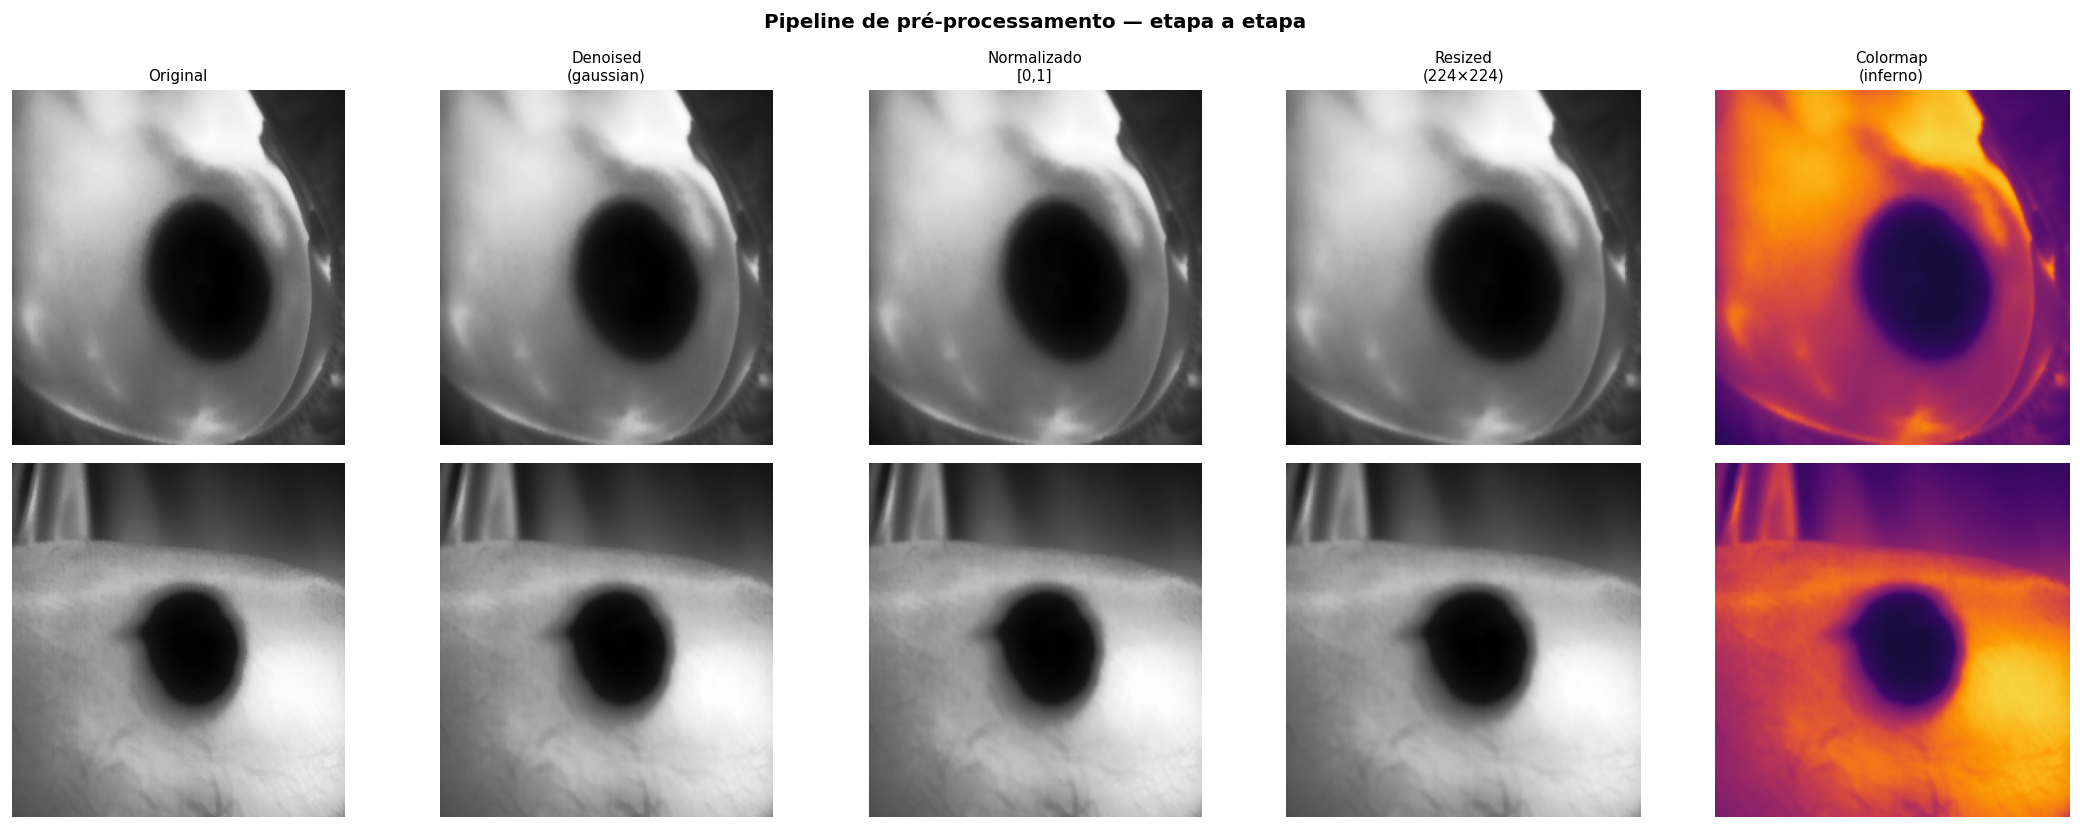

In [9]:
import cv2

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
stages = ['Original', 'Denoised\n(gaussian)', 'Normalizado\n[0,1]', 'Resized\n(224×224)', 'Colormap\n(inferno)']

for row, cls in enumerate(CLASSES):
    patient_dir = next(p for p in sorted((RAW_DIR / cls).iterdir()) if p.is_dir())
    path = sample_frame(patient_dir)

    raw   = load_thermal_image(path)
    den   = denoise(raw, 'gaussian')
    norm  = normalize(den)
    resz  = cv2.resize(norm, (224, 224), interpolation=cv2.INTER_AREA)
    cmap  = apply_colormap(resz, 'inferno')

    steps = [raw, den, norm, resz, cmap]
    cmaps = ['gray', 'gray', 'gray', 'gray', None]

    for col, (img, cm, stage) in enumerate(zip(steps, cmaps, stages)):
        ax = axes[row, col]
        ax.imshow(img, cmap=cm)
        if row == 0:
            ax.set_title(stage, fontsize=9)
        ax.set_ylabel(cls, fontsize=9) if col == 0 else None
        ax.axis('off')

        # Estatísticas no rodapé de cada célula
        arr = np.array(img)
        info = f'shape={arr.shape}\nmin={arr.min():.3f} max={arr.max():.3f}'
        ax.set_xlabel(info, fontsize=6.5)

plt.suptitle('Pipeline de pré-processamento — etapa a etapa', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/preprocessing_stages.png', bbox_inches='tight')
plt.show()

## 2. Histograma de pixels — antes e depois da normalização

Confirma que a distribuição de intensidades é preservada e que os valores caem corretamente em [0, 1] após normalização.

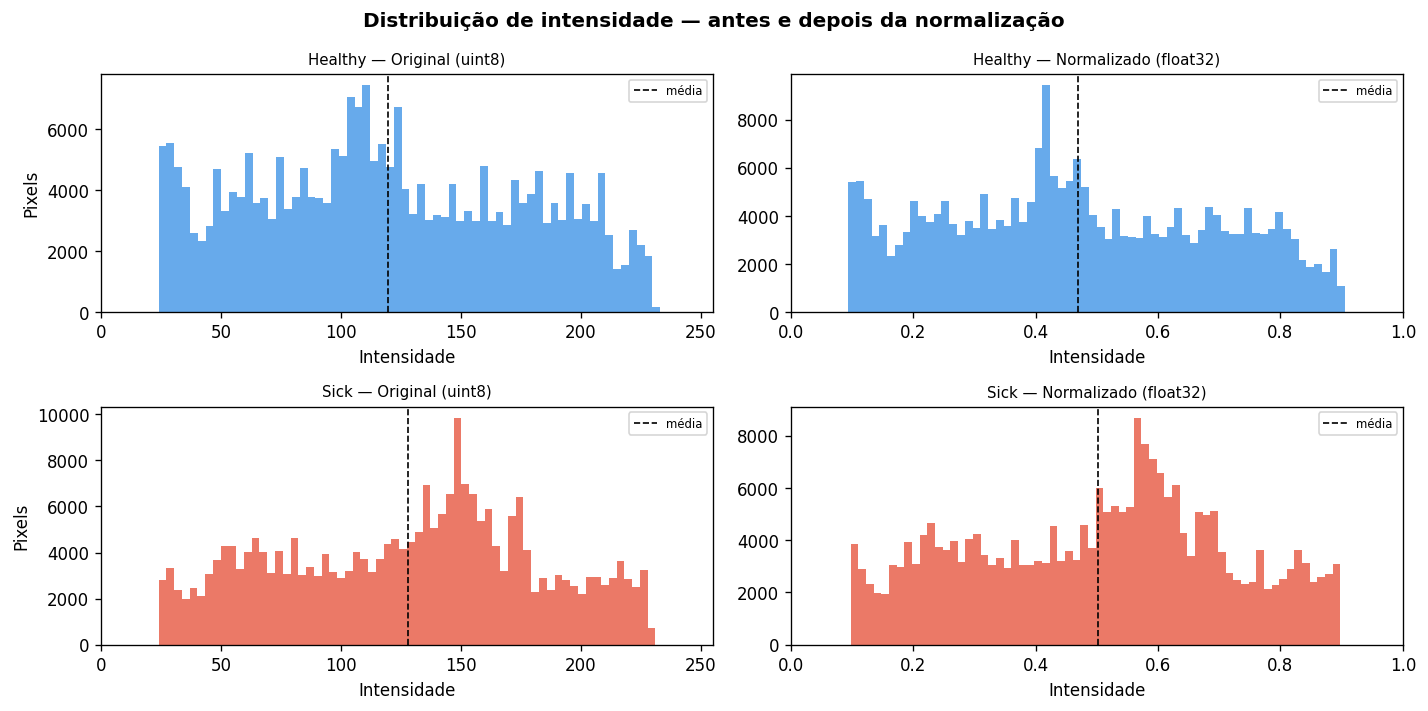

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
colors = {'Healthy': '#4C9BE8', 'Sick': '#E8624C'}

for row, cls in enumerate(CLASSES):
    patient_dir = next(p for p in sorted((RAW_DIR / cls).iterdir()) if p.is_dir())
    path = sample_frame(patient_dir)

    raw  = load_thermal_image(path)
    norm = normalize(denoise(raw, 'gaussian'))

    axes[row, 0].hist(raw.ravel(), bins=64, color=colors[cls], edgecolor='none', alpha=0.85)
    axes[row, 0].set_title(f'{cls} — Original (uint8)', fontsize=9)
    axes[row, 0].set_xlabel('Intensidade')
    axes[row, 0].set_ylabel('Pixels')
    axes[row, 0].set_xlim(0, 255)

    axes[row, 1].hist(norm.ravel(), bins=64, color=colors[cls], edgecolor='none', alpha=0.85)
    axes[row, 1].set_title(f'{cls} — Normalizado (float32)', fontsize=9)
    axes[row, 1].set_xlabel('Intensidade')
    axes[row, 1].set_xlim(0, 1)

    for ax in axes[row]:
        ax.axvline(raw.mean() / 255 if ax == axes[row, 1] else raw.mean(),
                   color='black', linestyle='--', linewidth=1, label='média')
        ax.legend(fontsize=7)

plt.suptitle('Distribuição de intensidade — antes e depois da normalização', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/preprocessing_histograms.png', bbox_inches='tight')
plt.show()

## 3. Comparação de métodos de denoising

Visualiza o efeito de gaussian, median e bilateral no mesmo frame para orientar a escolha.

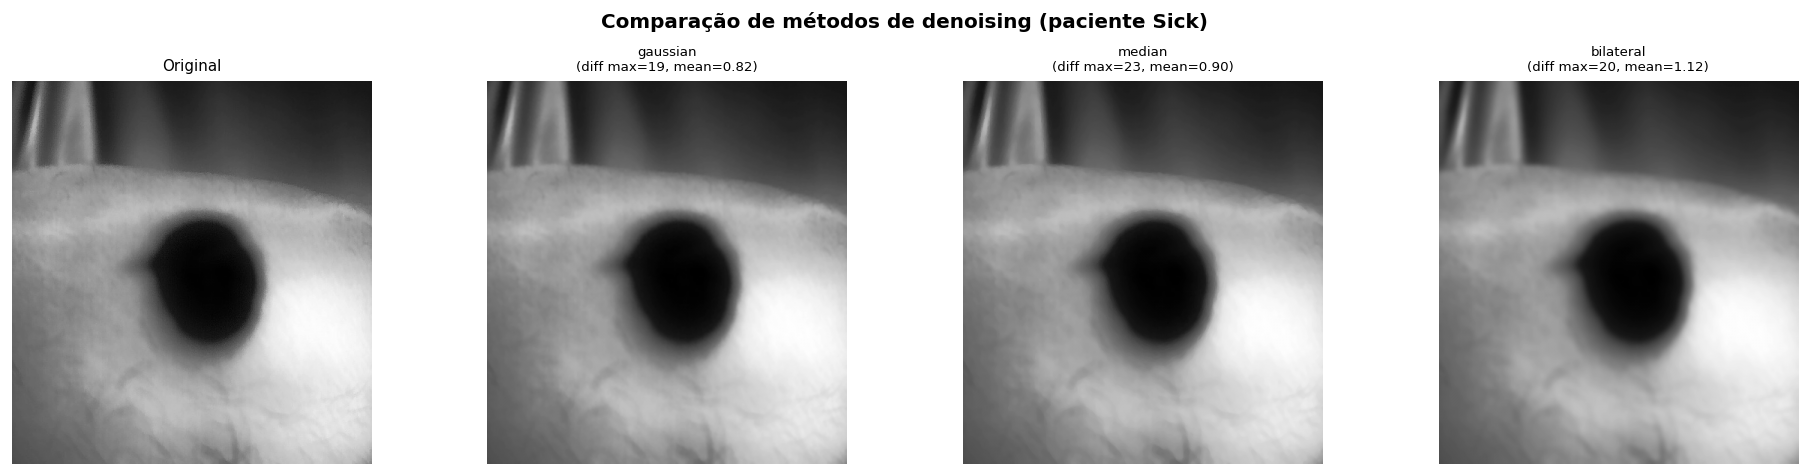

In [11]:
methods = ['gaussian', 'median', 'bilateral']
patient_dir = next(p for p in sorted((RAW_DIR / 'Sick').iterdir()) if p.is_dir())
path = sample_frame(patient_dir)
raw = load_thermal_image(path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(raw, cmap='gray')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for ax, method in zip(axes[1:], methods):
    den = denoise(raw, method)
    diff = np.abs(raw.astype(np.int16) - den.astype(np.int16))
    ax.imshow(den, cmap='gray')
    ax.set_title(f'{method}\n(diff max={diff.max()}, mean={diff.mean():.2f})', fontsize=8)
    ax.axis('off')

plt.suptitle('Comparação de métodos de denoising (paciente Sick)', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/denoising_comparison.png', bbox_inches='tight')
plt.show()

## 4. Rodar pipeline completo em subconjunto (3 pacientes por classe)

Executa `preprocess_dataset` em 3 pacientes por classe para validar performance e estrutura de saída antes de rodar no dataset inteiro.

In [12]:
import shutil, time

SUBSET_RAW  = Path('../data/raw/_subset_validation')
SUBSET_PROC = Path('../data/processed/_subset_validation')

# Monta subconjunto com 3 pacientes por classe
SUBSET_RAW.mkdir(parents=True, exist_ok=True)
N_PATIENTS = 3

for cls in CLASSES:
    patients = [p for p in sorted((RAW_DIR / cls).iterdir()) if p.is_dir()][:N_PATIENTS]
    for patient in patients:
        dst = SUBSET_RAW / cls / patient.name
        if not dst.exists():
            shutil.copytree(patient, dst)

total_frames = len(list(SUBSET_RAW.rglob('*.png')))
print(f'Subconjunto: {total_frames} frames de {N_PATIENTS * len(CLASSES)} pacientes')

# Roda pipeline
t0 = time.time()
preprocess_dataset(SUBSET_RAW, SUBSET_PROC, target_size=(224, 224))
elapsed = time.time() - t0

processed = list(SUBSET_PROC.rglob('*.png'))
print(f'\nProcessados: {len(processed)} frames em {elapsed:.1f}s ({elapsed/total_frames*1000:.1f} ms/frame)')
print(f'Taxa estimada para dataset completo (~108k frames): {108548 * elapsed / total_frames / 60:.1f} min')

Subconjunto: 3990 frames de 6 pacientes


Preprocessing: 100%|██████████| 3990/3990 [00:19<00:00, 199.61it/s]


Processados: 3990 frames em 20.0s (5.0 ms/frame)
Taxa estimada para dataset completo (~108k frames): 9.1 min


## 5. Verificar estrutura e integridade da saída

Confirma que: (a) todos os arquivos foram gerados, (b) as dimensões são 224×224, (c) os valores estão no range esperado [0, 255] uint8.

In [13]:
import random

processed_files = sorted(SUBSET_PROC.rglob('*.png'))
raw_files       = sorted(SUBSET_RAW.rglob('*.png'))

# (a) Contagem igual
assert len(processed_files) == len(raw_files), (
    f'Frames perdidos: {len(raw_files)} raw vs {len(processed_files)} processed'
)
print(f'[OK] Contagem: {len(processed_files)} arquivos gerados == {len(raw_files)} raw')

# (b) e (c) Amostra aleatória de 20 imagens
errors = []
sample = random.sample(processed_files, min(20, len(processed_files)))
for f in sample:
    img = np.array(Image.open(f))
    if img.shape != (224, 224):
        errors.append(f'Shape inesperado {img.shape}: {f}')
    if img.dtype != np.uint8:
        errors.append(f'Dtype inesperado {img.dtype}: {f}')
    if img.max() == 0:
        errors.append(f'Imagem vazia: {f}')

if errors:
    for e in errors:
        print('[ERRO]', e)
else:
    print('[OK] Shape: todas as amostras são (224, 224) uint8')
    print('[OK] Pixels: nenhuma imagem vazia')

# Estrutura de diretórios
print()
print('Estrutura de saída:')
for cls in CLASSES:
    patients = sorted((SUBSET_PROC / cls).iterdir())
    frames_total = sum(len(list(p.glob('*.png'))) for p in patients if p.is_dir())
    print(f'  {cls}: {len(patients)} pacientes, {frames_total} frames')

[OK] Contagem: 3990 arquivos gerados == 3990 raw
[OK] Shape: todas as amostras são (224, 224) uint8
[OK] Pixels: nenhuma imagem vazia

Estrutura de saída:
  Healthy: 3 pacientes, 1801 frames
  Sick: 3 pacientes, 2189 frames


## 6. Rodar pipeline no dataset completo

Execute esta célula **uma vez** para gerar `data/processed/TR_heatSkin/`. Pode levar alguns minutos dependendo do hardware.

In [14]:
if PROC_DIR.exists() and any(PROC_DIR.rglob('*.png')):
    print(f'data/processed já existe com {len(list(PROC_DIR.rglob("*.png")))} frames — pulando.')
else:
    print('Rodando pipeline no dataset completo...')
    t0 = time.time()
    preprocess_dataset(RAW_DIR, PROC_DIR, target_size=(224, 224))
    elapsed = time.time() - t0
    total = len(list(PROC_DIR.rglob('*.png')))
    print(f'Concluído: {total} frames em {elapsed/60:.1f} min')

data/processed já existe com 108548 frames — pulando.


## 7. Dinâmica térmica — sequência temporal de um paciente

Mostra frames igualmente espaçados ao longo da sequência completa de um paciente, revelando as três fases do protocolo DTI: aquecimento inicial → resfriamento → retorno à temperatura basal.

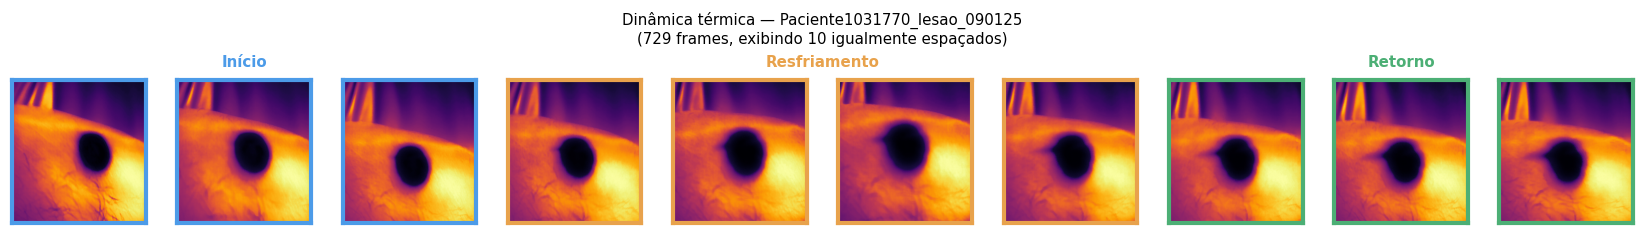

In [18]:
N_COLS = 10

PHASES = [
    {'label': 'Início',       'cols': range(0, 3),  'color': '#4C9BE8'},
    {'label': 'Resfriamento', 'cols': range(3, 7),  'color': '#E8A24C'},
    {'label': 'Retorno',      'cols': range(7, 10), 'color': '#4CAF75'},
]

def phase_of(col):
    for p in PHASES:
        if col in p['cols']:
            return p

patient_dir = next(p for p in sorted((RAW_DIR / 'Sick').iterdir()) if p.is_dir())
frames = sorted(patient_dir.glob('*.png'))
n = len(frames)
indices = [int(round(i * (n - 1) / (N_COLS - 1))) for i in range(N_COLS)]

fig, axes = plt.subplots(1, N_COLS, figsize=(14, 2.2))
fig.subplots_adjust(wspace=0.04, top=0.72, bottom=0.18, left=0.01, right=0.99)

for col, idx in enumerate(indices):
    ax = axes[col]
    ax.imshow(load_thermal_image(frames[idx]), cmap='inferno')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(phase_of(col)['color'])
        spine.set_linewidth(2.5)

for phase in PHASES:
    cols = list(phase['cols'])
    x0 = axes[cols[0]].get_position().x0
    x1 = axes[cols[-1]].get_position().x1
    y1 = axes[0].get_position().y1
    fig.text((x0 + x1) / 2, y1 + 0.04, phase['label'],
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color=phase['color'])

fig.suptitle(f'Dinâmica térmica — {patient_dir.name}\n({n} frames, exibindo {N_COLS} igualmente espaçados)',
             fontsize=9, y=0.98)
plt.savefig('../results/thermal_dynamics.png', bbox_inches='tight')
plt.show()

## 8. Curva térmica — como a temperatura muda ao longo do tempo

Cada ponto do gráfico é a intensidade média de todos os pixels naquele frame. A diferença no padrão de reaquecimento entre Healthy e Sick é o sinal que a rede neural aprende a reconhecer.

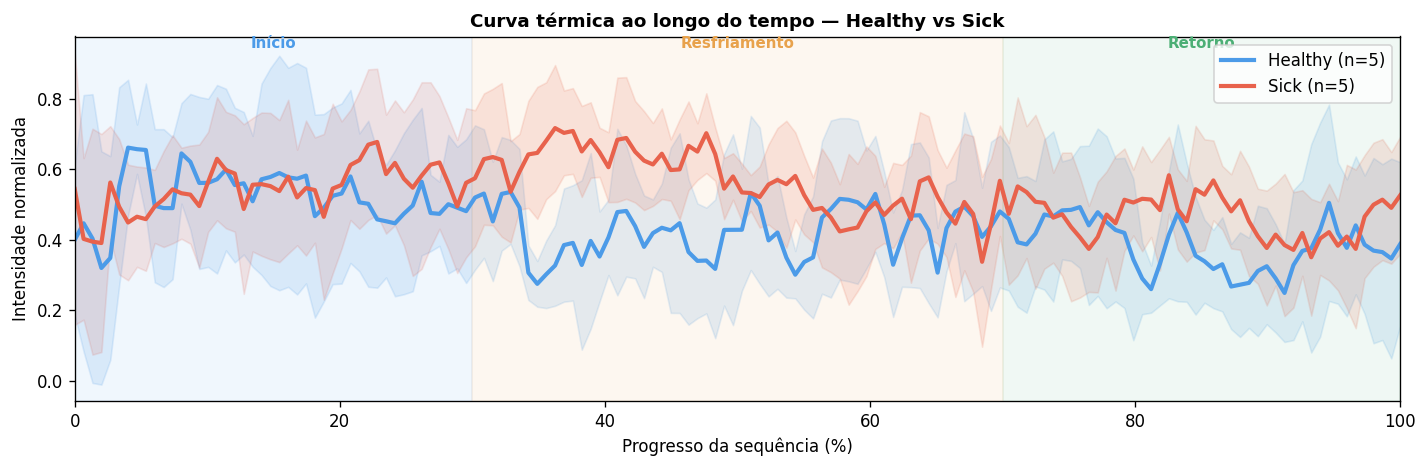

In [22]:
COLORS = {'Healthy': '#4C9BE8', 'Sick': '#E8624C'}
PHASE_SPANS = [
    {'label': 'Início',       'frac': (0.0, 0.3), 'color': '#4C9BE8'},
    {'label': 'Resfriamento', 'frac': (0.3, 0.7), 'color': '#E8A24C'},
    {'label': 'Retorno',      'frac': (0.7, 1.0), 'color': '#4CAF75'},
]

N_PATIENTS_CURVE = 5  # pacientes por classe para a média

fig, ax = plt.subplots(figsize=(12, 4))

for cls in CLASSES:
    patients = [p for p in sorted((RAW_DIR / cls).iterdir()) if p.is_dir()][:N_PATIENTS_CURVE]
    all_curves = []

    for patient_dir in patients:
        frames = sorted(patient_dir.glob('*.png'))
        n = len(frames)
        step = max(1, n // 150)
        sampled = frames[::step]
        means = [np.array(Image.open(f).convert('L')).mean() for f in sampled]
        # normaliza para [0,1] dentro de cada paciente para comparar padrão, não magnitude
        arr = np.array(means, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        # interpola para 150 pontos para poder fazer média entre pacientes
        xs_norm = np.linspace(0, 1, 150)
        xs_orig = np.linspace(0, 1, len(arr))
        all_curves.append(np.interp(xs_norm, xs_orig, arr))

    mean_curve = np.mean(all_curves, axis=0)
    std_curve  = np.std(all_curves, axis=0)
    xs_pct = np.linspace(0, 100, 150)

    ax.plot(xs_pct, mean_curve, color=COLORS[cls], linewidth=2.5, label=f'{cls} (n={len(patients)})')
    ax.fill_between(xs_pct, mean_curve - std_curve, mean_curve + std_curve,
                    color=COLORS[cls], alpha=0.15)

# faixas de fase
for phase in PHASE_SPANS:
    x0, x1 = phase['frac'][0] * 100, phase['frac'][1] * 100
    ax.axvspan(x0, x1, alpha=0.08, color=phase['color'])

# labels de fase no topo do gráfico
y_top = ax.get_ylim()[1]
for phase in PHASE_SPANS:
    x0, x1 = phase['frac'][0] * 100, phase['frac'][1] * 100
    ax.text((x0 + x1) / 2, y_top, phase['label'],
            ha='center', va='top', fontsize=9,
            color=phase['color'], fontweight='bold',
            transform=ax.transData)

ax.set_xlabel('Progresso da sequência (%)', fontsize=10)
ax.set_ylabel('Intensidade normalizada', fontsize=10)
ax.set_title('Curva térmica ao longo do tempo — Healthy vs Sick', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('../results/thermal_curve.png', bbox_inches='tight')
plt.show()

## 9. Mapa de diferença térmica — onde a temperatura mais mudou

Subtrai o primeiro frame do último. As regiões mais claras são onde a temperatura mais se alterou durante o exame — geralmente coincide com a área da lesão.

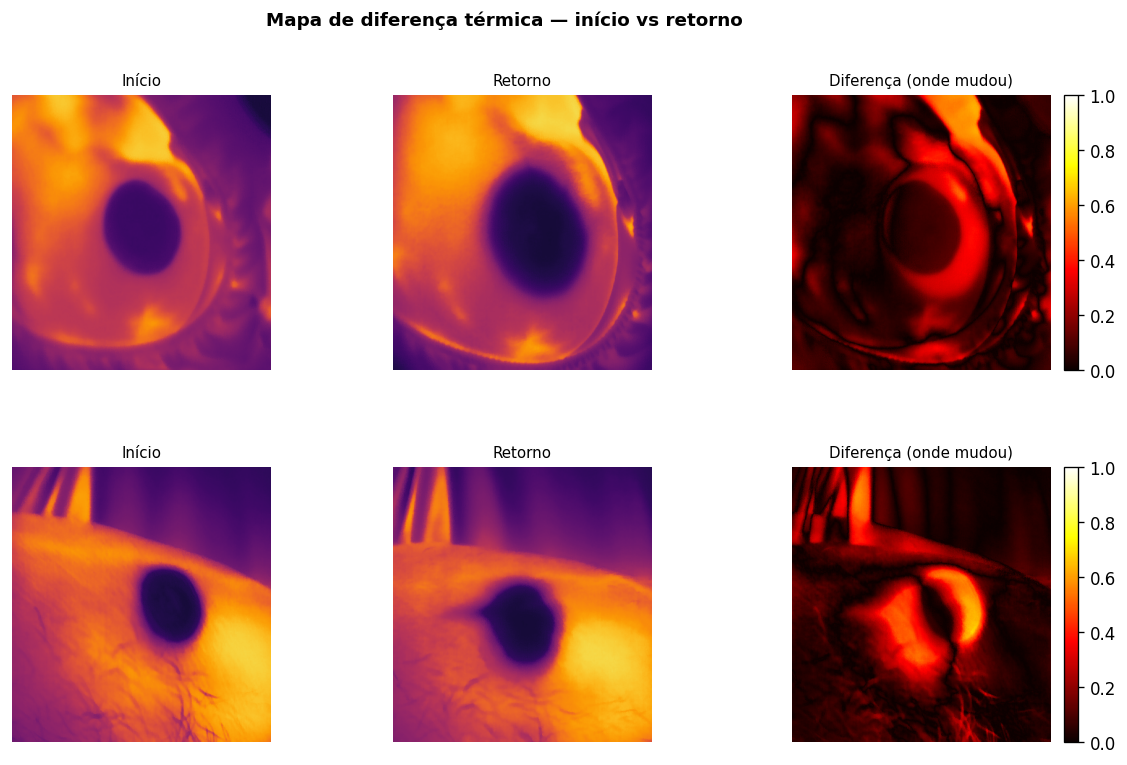

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.subplots_adjust(hspace=0.35, wspace=0.08)

for row, cls in enumerate(CLASSES):
    patient_dir = next(p for p in sorted((RAW_DIR / cls).iterdir()) if p.is_dir())
    frames = sorted(patient_dir.glob('*.png'))

    first = np.array(Image.open(frames[0]).convert('L')).astype(np.float32) / 255.0
    last  = np.array(Image.open(frames[-1]).convert('L')).astype(np.float32) / 255.0
    diff  = np.abs(last - first)

    imgs   = [first,     last,      diff]
    titles = ['Início', 'Retorno', 'Diferença (onde mudou)']
    cmaps  = ['inferno', 'inferno', 'hot']

    for col, (img, title, cmap) in enumerate(zip(imgs, titles, cmaps)):
        ax = axes[row, col]
        im = ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, labelpad=6)
        if col == 2:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Mapa de diferença térmica — início vs retorno', fontsize=11, fontweight='bold')
plt.savefig('../results/thermal_diff_map.png', bbox_inches='tight')
plt.show()